<a href="https://colab.research.google.com/github/Ishu250412/ishu_jecrc_cei/blob/main/Week2_Ishu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
df = pd.read_csv("/content/tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


**EDA**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [ ]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [ ]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


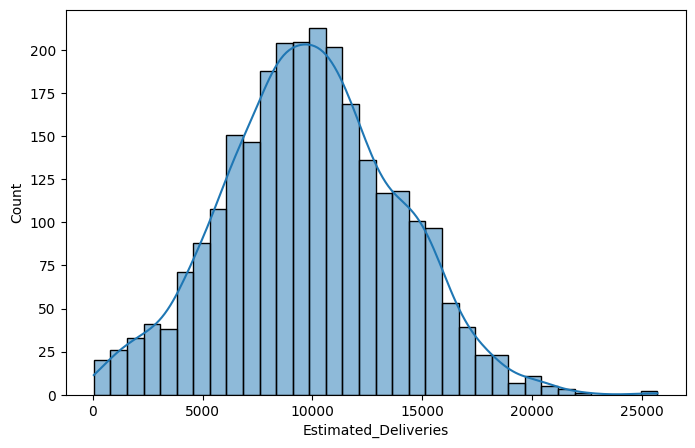

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Estimated_Deliveries"], kde=True)
plt.show()

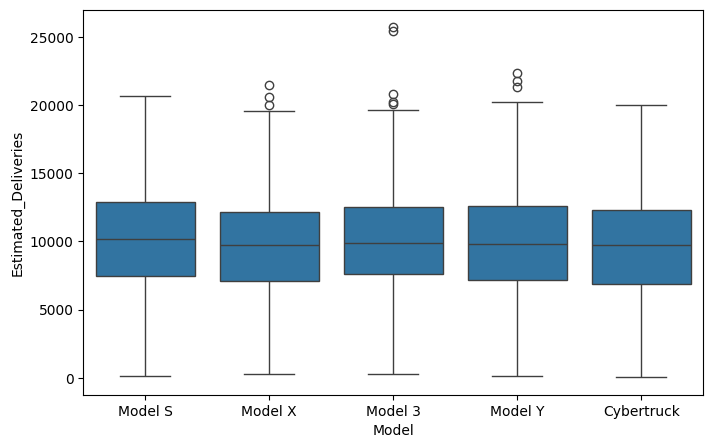

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
x="Model",
y="Estimated_Deliveries",
data=df
)
plt.show()

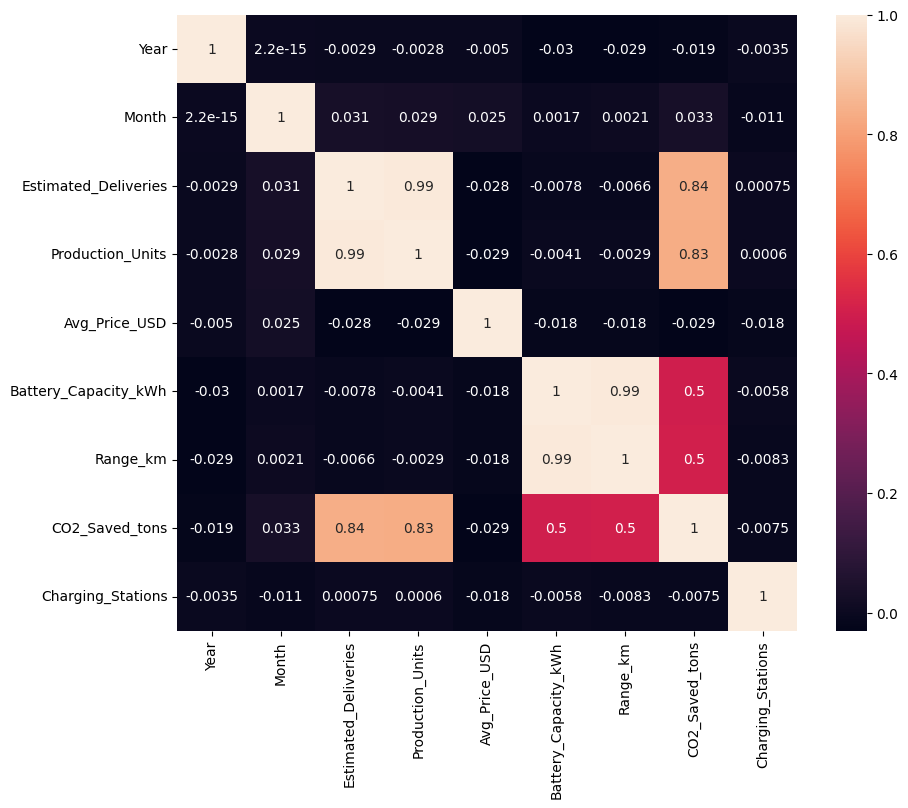

In [ ]:
  plt.figure(figsize=(10,8))

sns.heatmap(
df.select_dtypes(include=np.number).corr(),
annot=True
)

plt.show()

**Feature Engineering**

In [ ]:
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df["Region"] = le_region.fit_transform(df["Region"])

df["Model"] = le_model.fit_transform(df["Model"])

df["Source_Type"] = le_source.fit_transform(df["Source_Type"])

In [ ]:
X = df.drop(
"Estimated_Deliveries",
axis=1
)

y = df["Estimated_Deliveries"]

**Train test Split**

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

**Regression Model**

In [ ]:
rf = RandomForestRegressor(
random_state=42
)

rf.fit(
X_train,
y_train
)

RandomForestRegressor(random_state=42)

In [ ]:
predictions = rf.predict(X_test)

**Evaluation**

In [ ]:
print("MAE:",
      mean_absolute_error(
      y_test,
      predictions))

print("RMSE:",
      np.sqrt(
      mean_squared_error(
      y_test,
      predictions)))

print("R2:",
      r2_score(
      y_test,
      predictions))

MAE: 323.46011363636364
RMSE: 409.4960252956731
R2: 0.9887505867840798


**Hyperparameter Tuning**

In [ ]:
param_grid = {
'n_estimators':[100,200],
'max_depth':[10,20,None]
}

grid = GridSearchCV(
RandomForestRegressor(
random_state=42),
param_grid,
cv=3,
n_jobs=-1
)

grid.fit(
X_train,
y_train
)

print(grid.best_params_)

{'max_depth': 20, 'n_estimators': 100}


**Time Series Forecasting**

In [ ]:
df["Date"] = pd.to_datetime(
df["Year"].astype(str)
+
"-"
+
df["Month"].astype(str)
)

In [ ]:
monthly = df.groupby(
"Date"
)["Estimated_Deliveries"].sum()

In [ ]:
pip install statsmodels

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
monthly,
trend="add"
)

fit = model.fit()

forecast = fit.forecast(12)

print(forecast)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2026-01-01    199247.808646
2026-02-01    199352.936079
2026-03-01    199458.063512
2026-04-01    199563.190945
2026-05-01    199668.318378
2026-06-01    199773.445811
2026-07-01    199878.573243
2026-08-01    199983.700676
2026-09-01    200088.828109
2026-10-01    200193.955542
2026-11-01    200299.082975
2026-12-01    200404.210408
Freq: MS, dtype: float64


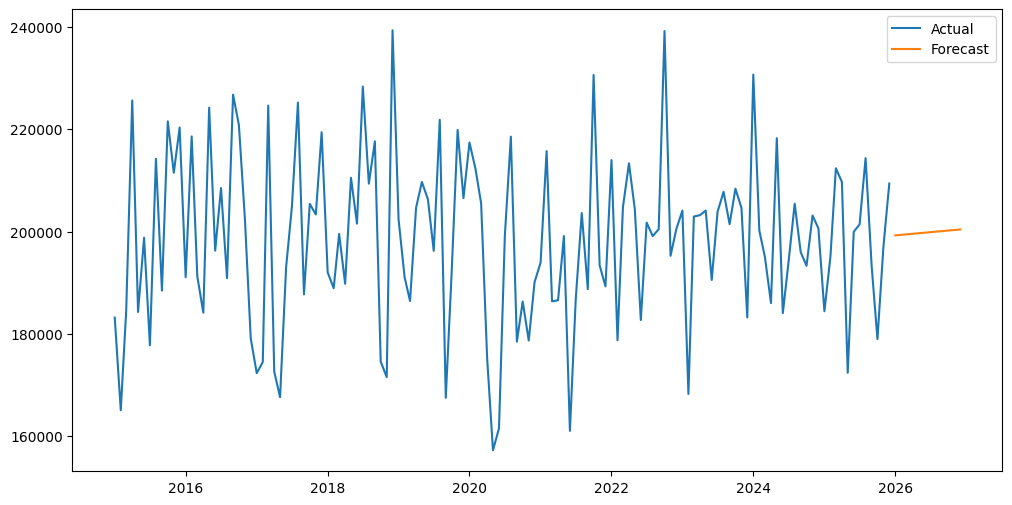

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
monthly,
label="Actual"
)

plt.plot(
forecast,
label="Forecast"
)

plt.legend()

plt.show()